In [1]:
%cd /sc/home/alexander.rakowski/deep-vep

/sc/home/alexander.rakowski/deep-vep


In [2]:
import src.snakemake_config as config

In [3]:
import collections
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [4]:
mifm_model_id = 'c5h35z87'

topks = (
    1,
    5,
    10,
)

In [5]:
CATEGORIES = [
    'better (corrected)',
    'better',
    'tie',
    'worse',
    'worse (corrected)',
]   
CATEGORIES = [
    'Better ($p < 0.0005$)',
    'Better ($0.0005 < p < 0.05$)',
    '$p > 0.05$',
    'Worse ($0.0005 < p < 0.05$)',
    'Worse ($p < 0.0005$)',
]   


def diff_to_str(row):
    diff_obs, pval = row['diff_obs'], row['pval']
    
    if diff_obs > 0:
        if pval < .05 / 100:
            return CATEGORIES[0]
        elif pval < .05:
            return CATEGORIES[1]
    else:
        if pval < .05 / 100:
            return CATEGORIES[-1]
        elif pval < .05:
            return CATEGORIES[-2]
    
    return CATEGORIES[2]


dfs_topk = {}
for topk in topks:
    mifm_model_name = mifm_model_id if topk == 1 else f'{mifm_model_id}_top{topk}_cws'

    dfs = []
    for p in tqdm(Path(f'results/permutation_tests_secondary/{mifm_model_name}/CT_alt_1/').glob('*/*/*/0/ukbfull/*/results.tsv')):
        model_id_2 = p.parts[-7]
        if topk == 1 and '_top' in model_id_2:
            continue
        if topk > 1 and f'_top{topk}_cws' not in model_id_2:
            continue
        
        min_variants_coverage = p.parent.parent.parent.name
        df = pd.read_csv(p, sep='\t')
        df['min_variants_coverage'] = min_variants_coverage

        pgs_id = p.parent.parent.parent.parent.name

        try:
            p_model_1 = f"results/pgs_secondary/{pgs_id}/{df['model_id_1'].iloc[0]}/0/{df['pgs_id_1'].iloc[0]}/ukbfull/{df['ukb_field_id'].iloc[0]}/results.tsv"
            df_model_1 = pd.read_csv(p_model_1, sep='\t').rename(columns={'r2': 'r2_model_1'}).rename(columns={'mcfadden_r2': 'r2_model_1'})
            p_model_2 = Path(f"results/pgs_secondary/{pgs_id}/{df['model_id_2'].iloc[0]}/0/{df['pgs_id_2'].iloc[0]}/ukbfull/{df['ukb_field_id'].iloc[0]}/results.tsv")
            if not p_model_2.exists():
                print(f'Could not find:\n{p_model_2}')
                p_model_2 = Path(f"results/pgs_secondary/{pgs_id}/{df['model_id_2'].iloc[0]}/0/CT_p_1/ukbfull/{df['ukb_field_id'].iloc[0]}/results.tsv")
            df_model_2 = pd.read_csv(p_model_2, sep='\t').rename(columns={'r2': 'r2_model_2'}).rename(columns={'mcfadden_r2': 'r2_model_2'})

            df = df.merge(df_model_1[['r2_model_1', 'pop']], on='pop')
            df = df.merge(df_model_2[['r2_model_2', 'pop']], on='pop')

            dfs.append(df)
        except Exception as e:
            print(e)

    df = pd.concat(dfs)
    df = df.loc[
        (~df['ukb_field_id'].isin((
            '30010-0.0',
            '21002-0.0',
            '3148-0.0',
        )))
    ]

    df['y_type'] = df['metric'].apply(lambda m: 'binary' if m == 'mcfadden_r2' else 'continuous')
    df['metric'] = df['metric'].apply(lambda m: 'r2' if m == 'mcfadden_r2' else m)
    df = df.query('metric == "r2"')
    df['model_id_2'] = df['model_id_2'].str.replace('all', 'pvalue')

    df['better'] = df['diff_obs'] >= 0
    df['p_better'] = df.apply(lambda r: r['pval'] if r['better'] else 1 - r['pval'], axis=1)
    df['p_log'] = df['pval'].apply(np.log10)
    df['p_log_quant'] = df['p_log'].round(0)

    MIN_LOG_PVAL = -8
    df['p_log_quant'] = df['p_log_quant'].apply(lambda p: MIN_LOG_PVAL if str(p) == '-inf' else p)
    df['p_log'] = df['p_log'].apply(lambda p: MIN_LOG_PVAL if str(p) == '-inf' else p)
    df['p_special'] = df.apply(
        lambda row: row['p_log_quant'] if row['p_log_quant'] < -4 else (0.0005 if row['pval'] < 0.0005 else row['p_log_quant']),
        axis=1,
    )
    df['p_special'] = df['p_special'].astype(str)


    df = df.drop_duplicates(['ukb_field_id', 'model_id_2', 'model_id_1', 'pop'])
    df = df[
        (~df['model_id_2'].str.endswith('top5'))
        & ((~df['model_id_2'].str.endswith('top10')))
    ]
    
    df['diff_quantized'] = df.apply(diff_to_str, axis=1)
    df['diff_quantized'] = pd.Categorical(
        df['diff_quantized'], 
        CATEGORIES,
    )
    
    dfs_topk[topk] = df

897it [00:08, 107.44it/s]
897it [00:08, 107.14it/s]
897it [00:10, 83.98it/s] 


In [6]:
model_names = {
    'pvalue': 'p-value',
    'basenji2_normalized': 'Basenji2',
    'sei': 'DeepSEA-SEI',
    'enformer_normalized': 'Enformer',
    'cadd': 'CADD',
    'abf': 'ABF',
    'caviarbf': 'CAVIARBF',
    'finemap': 'FINEMAP',
    'paintor': 'PAINTOR',
    'susie': 'SuSiE',
    'polyfun_finemap': 'PolyFun FINEMAP',
    'polyfun_susie': 'PolyFun SuSiE',
}
model_order = [
    'p-value',
    'Basenji2',
    'DeepSEA-SEI',
    'Enformer',
    'CADD',
    'ABF',
    'CAVIARBF',
    'FINEMAP',
    'PAINTOR',
    'SuSiE',
    'PolyFun FINEMAP',
    'PolyFun SuSiE',
]

for topk in (5, 10):
    for model_name in (
        'pvalue',
        'basenji2_normalized',
        'sei',
        'enformer_normalized',
        'cadd',
        'abf',
        'caviarbf',
        'finemap',
        'paintor',
        'susie',
        'polyfun_finemap',
        'polyfun_susie',
    ):
        model_names[f'{model_name}_top{topk}_cws'] = f"{model_names[model_name]}_top{topk}"
        model_order.append(f"{model_names[model_name]}_top{topk}")


def barplot(results, category_names, bar_height=.5, figsize=(9.2, 5), legend_offset=-.18):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    category_colors = plt.colormaps['RdYlGn'](
        np.linspace(0.85, 0.15, data.shape[1]))
    category_colors[2] = [.7, .7, .7, 1]

    fig, ax = plt.subplots(figsize=figsize)
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=bar_height,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
        ax.bar_label(rects, labels=[w if w > 0 else '' for w in widths], label_type='center', color=text_color)
    ax.legend(ncols=len(category_names), bbox_to_anchor=(
        legend_offset,
        1.05),
        loc='lower left', fontsize='small')

    return fig, ax



better    15.0
1         11.0
2         58.0
3         12.0
worse      3.0
dtype: float64

p-value 20
Basenji2 6
DeepSEA-SEI 12
Enformer 2
CADD 10
ABF 12
CAVIARBF 12
FINEMAP 14
PAINTOR 15
SuSiE 14
PolyFun FINEMAP 12
PolyFun SuSiE 13


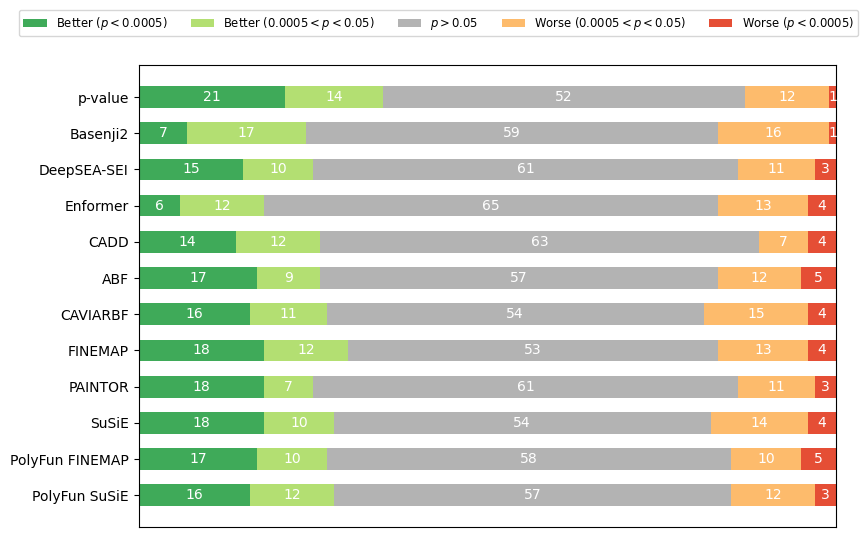

better    14.0
1         14.0
2         59.0
3         10.0
worse      4.0
dtype: float64

p-value_top5 11
Basenji2_top5 10
DeepSEA-SEI_top5 7
Enformer_top5 5
CADD_top5 1
ABF_top5 8
CAVIARBF_top5 14
FINEMAP_top5 13
PAINTOR_top5 13
SuSiE_top5 13
PolyFun FINEMAP_top5 15
PolyFun SuSiE_top5 9


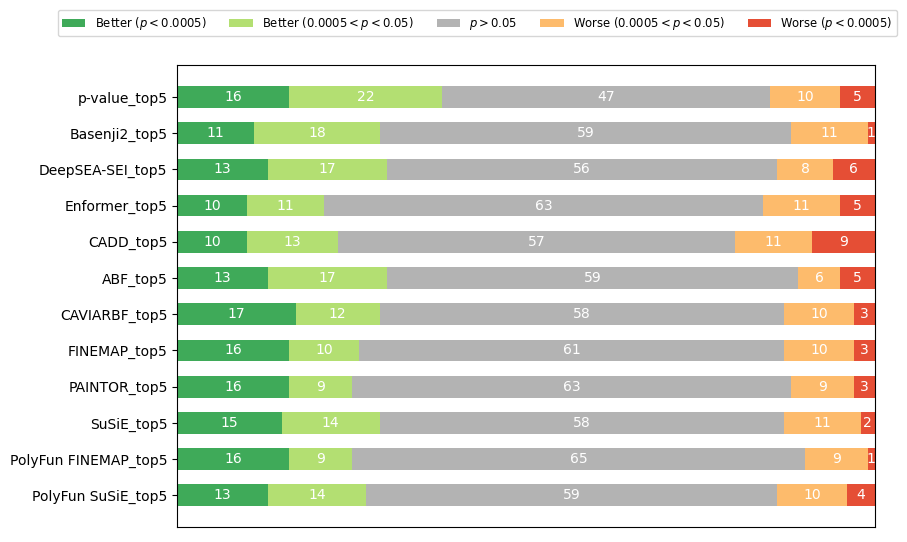

better    13.0
1         15.0
2         59.0
3         10.0
worse      3.0
dtype: float64

p-value_top10 11
Basenji2_top10 3
DeepSEA-SEI_top10 4
Enformer_top10 -2
CADD_top10 7
ABF_top10 9
CAVIARBF_top10 13
FINEMAP_top10 11
PAINTOR_top10 16
SuSiE_top10 14
PolyFun FINEMAP_top10 14
PolyFun SuSiE_top10 12


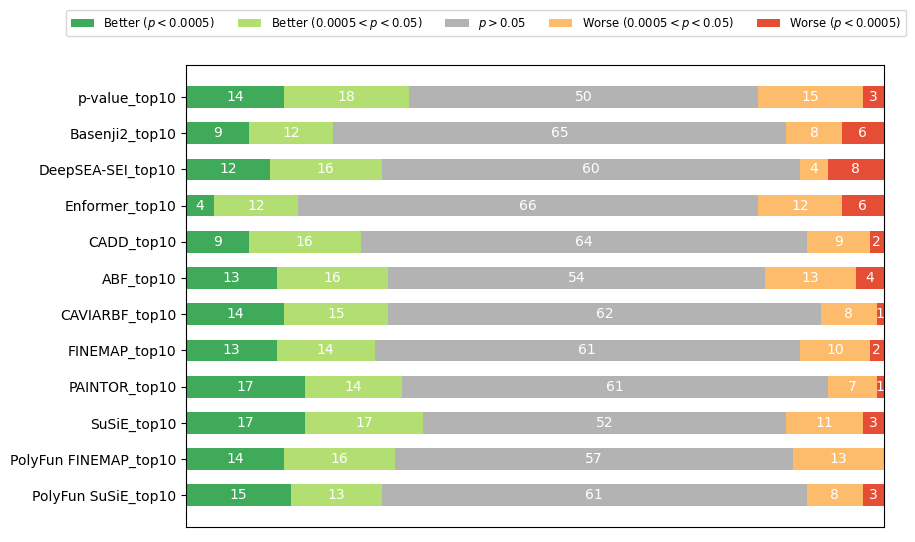

In [41]:
for topk in topks:
    df = dfs_topk[topk]
    results = {
        model_names[model_id_2]: group['diff_quantized'].value_counts(sort=False).to_list()
        for model_id_2, group in df[df['model_id_2'].isin(model_names.keys())].groupby('model_id_2')
    }
    results = collections.OrderedDict([(k, results[k]) for k in model_order if k in results])
    
    print(pd.DataFrame(results).T.rename(columns={0: 'better', 4: 'worse'}).mean().round())
    print()
    for k, v in results.items():
        print(k, v[0] - v[-1])
    
    barplot(
        results, 
        CATEGORIES,
        figsize=(9, 6),
        bar_height=.6,
    )
    plt.show()

# Per-ancestry results

AFR [0.19 0.11 0.55 0.14 0.01]
AMR [0.09 0.13 0.6  0.14 0.05]
CSA [0.18 0.1  0.55 0.13 0.04]
EAS [0.17 0.1  0.66 0.07 0.  ]
MID [0.14 0.13 0.52 0.13 0.08]


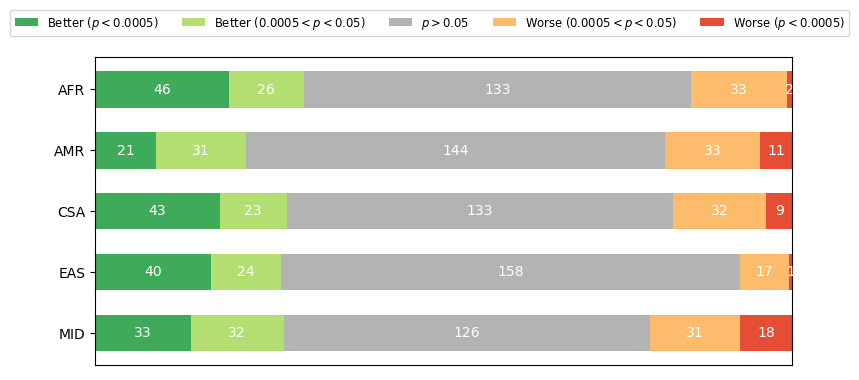

AFR [0.13 0.14 0.52 0.12 0.08]
AMR [0.11 0.17 0.59 0.1  0.04]
CSA [0.2  0.15 0.51 0.11 0.02]
EAS [0.15 0.12 0.63 0.07 0.03]
MID [0.09 0.11 0.69 0.08 0.02]


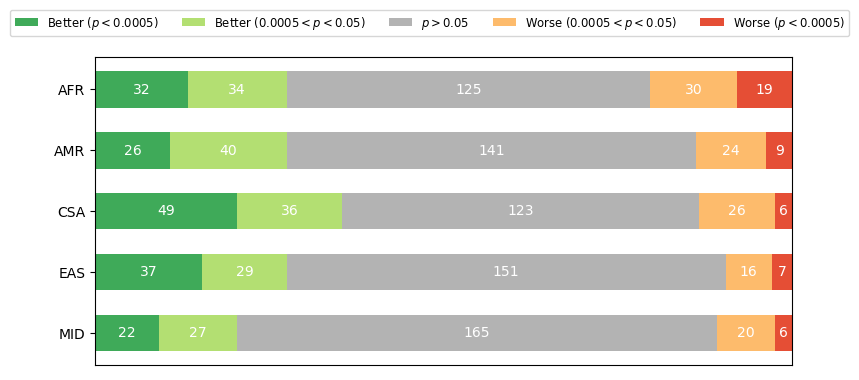

AFR [0.11 0.18 0.51 0.11 0.08]
AMR [0.12 0.15 0.6  0.08 0.04]
CSA [0.25 0.17 0.46 0.1  0.01]
EAS [0.06 0.08 0.72 0.12 0.02]
MID [0.08 0.16 0.68 0.08 0.01]


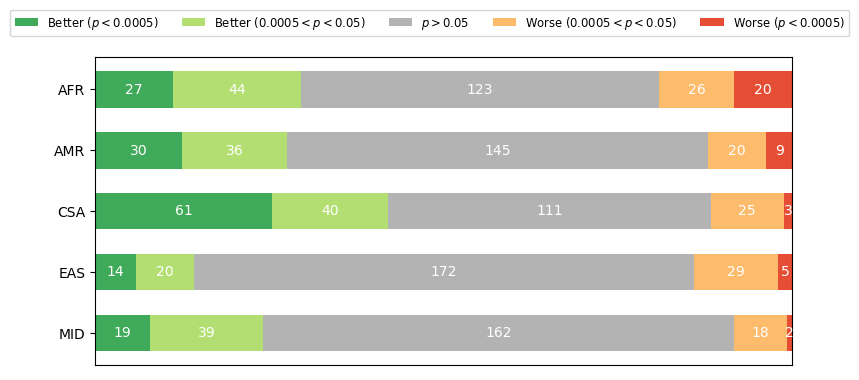

In [44]:
def plot_ancestry(df, topk):
    results_ancestry = {
        ancestry: group['diff_quantized'].value_counts(sort=False).to_list()
        for ancestry, group in df[df['model_id_2'].isin(model_names.keys())].groupby('pop')
    }
    
    for k, v in results_ancestry.items():
        print(k, (np.array(v) / sum(v)).round(2))

    barplot(
        results_ancestry, 
        CATEGORIES,
        figsize=(9, 4),
        bar_height=.6,
        legend_offset=-.13,
    )
    plt.savefig(f'pgs_results_ancestry_top{topk}.png', dpi=300, bbox_inches = "tight")
    plt.show()
    

for topk in topks:
    df = dfs_topk[topk]
    plot_ancestry(df, topk)

# Per-trait results

In [27]:
def format_field_name(field_name):
    return {
        'T2D': 'Type 2 diabetes',
        'IPF': 'Idiopathic pulmonary fibrosis',
        'J10_ASTHMA': 'Asthma',
        'K11_IBD_STRICT': 'Inflammatory bowel disease',
        'N14_CHRONKIDNEYDIS': 'Chronic kidney disease',
        'C3_PROSTATE': 'Prostate cancer',
        'C3_BREAST': 'Breast cancer',
        'G6_AD_WIDE': "Alzheimer's disease",
        'I9_CHD': 'Coronary heart disease',
        'RHEUMA_SEROPOS_OTH': 'Rheumatoid arthritis',
        '30880-0.0': 'Urate',
        '30760-0.0': 'HDL cholesterol',
        '12336-2.0': 'Ventricular rate',
        '21001-0.0': 'Body mass index',
        '3062-0.0': 'Forced vital capacity',
        '5262-0.0': 'Intra-ocular pressure',
        '30000-0.0': 'White blood cell count',
        '30740-0.0': 'Glucose',
        '30870-0.0': 'Triglycerides',
        '30770-0.0': 'Insulin-like growth factor 1',
    }.get(field_name, field_name)

,0,1,2,3,4,5,net
0,Inflammatory bowel disease,0.05,0.13,0.42,0.15,0.25,-0.20
1,Glucose,0.02,0.03,0.77,0.07,0.12,-0.10
2,Prostate cancer,0.02,0.13,0.70,0.10,0.05,-0.03
3,Chronic kidney disease,0.00,0.02,0.78,0.18,0.02,-0.02
4,Alzheimer's disease,0.00,0.05,0.68,0.27,0.00,0.00
7,Coronary heart disease,0.03,0.23,0.70,0.02,0.02,0.01
8,Idiopathic pulmonary fibrosis,0.03,0.03,0.85,0.07,0.02,0.01
5,Body mass index,0.02,0.12,0.52,0.35,0.00,0.02
6,Intra-ocular pressure,0.02,0.15,0.62,0.22,0.00,0.02
9,Forced vital capacity,0.05,0.17,0.63,0.13,0.02,0.03


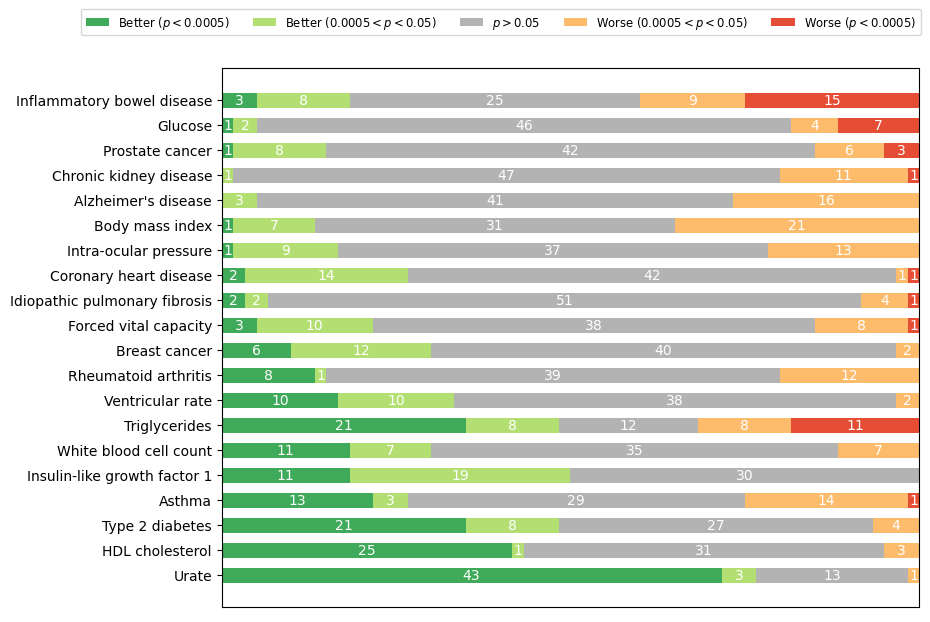

,0,1,2,3,4,5,net
0,Type 2 diabetes,0.00,0.07,0.65,0.18,0.10,-0.10
2,Insulin-like growth factor 1,0.02,0.08,0.65,0.18,0.07,-0.05
1,Body mass index,0.07,0.15,0.60,0.07,0.12,-0.05
3,Inflammatory bowel disease,0.03,0.12,0.55,0.23,0.07,-0.04
4,Chronic kidney disease,0.00,0.17,0.65,0.17,0.02,-0.02
5,Prostate cancer,0.02,0.20,0.73,0.03,0.02,0.00
6,Alzheimer's disease,0.00,0.02,0.95,0.03,0.00,0.00
7,Idiopathic pulmonary fibrosis,0.07,0.02,0.78,0.07,0.07,0.00
8,Intra-ocular pressure,0.02,0.15,0.75,0.08,0.00,0.02
9,Asthma,0.07,0.13,0.67,0.08,0.05,0.02


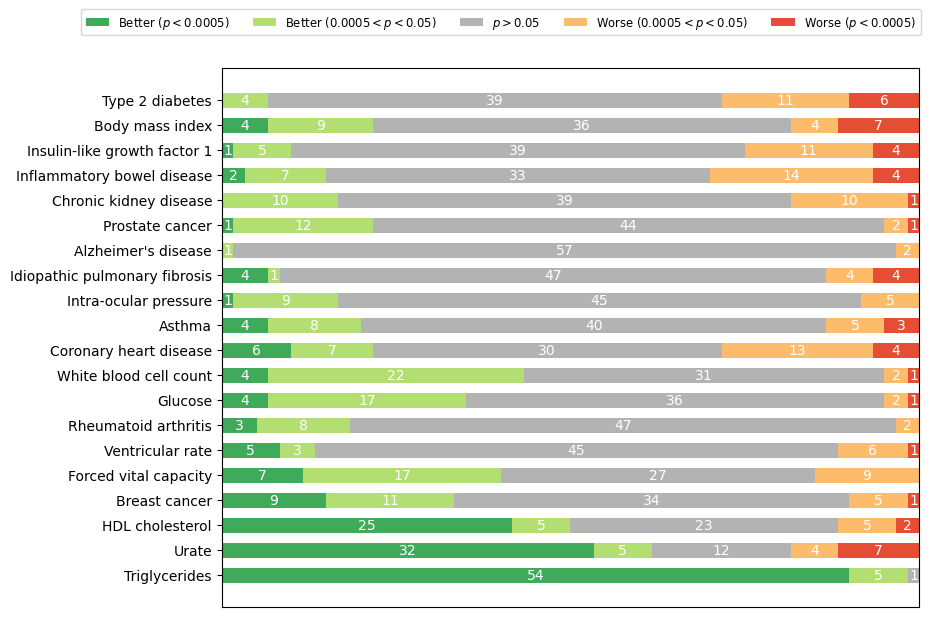

,0,1,2,3,4,5,net
0,Prostate cancer,0.02,0.00,0.50,0.38,0.10,-0.08
1,Insulin-like growth factor 1,0.02,0.10,0.67,0.15,0.07,-0.05
2,Asthma,0.03,0.13,0.65,0.10,0.08,-0.05
3,Idiopathic pulmonary fibrosis,0.00,0.18,0.73,0.08,0.00,0.00
4,Inflammatory bowel disease,0.00,0.07,0.80,0.13,0.00,0.00
5,Ventricular rate,0.03,0.18,0.72,0.05,0.02,0.01
9,Rheumatoid arthritis,0.03,0.33,0.48,0.13,0.02,0.01
7,Intra-ocular pressure,0.02,0.18,0.77,0.03,0.00,0.02
8,Alzheimer's disease,0.02,0.02,0.90,0.07,0.00,0.02
6,Body mass index,0.05,0.17,0.50,0.25,0.03,0.02


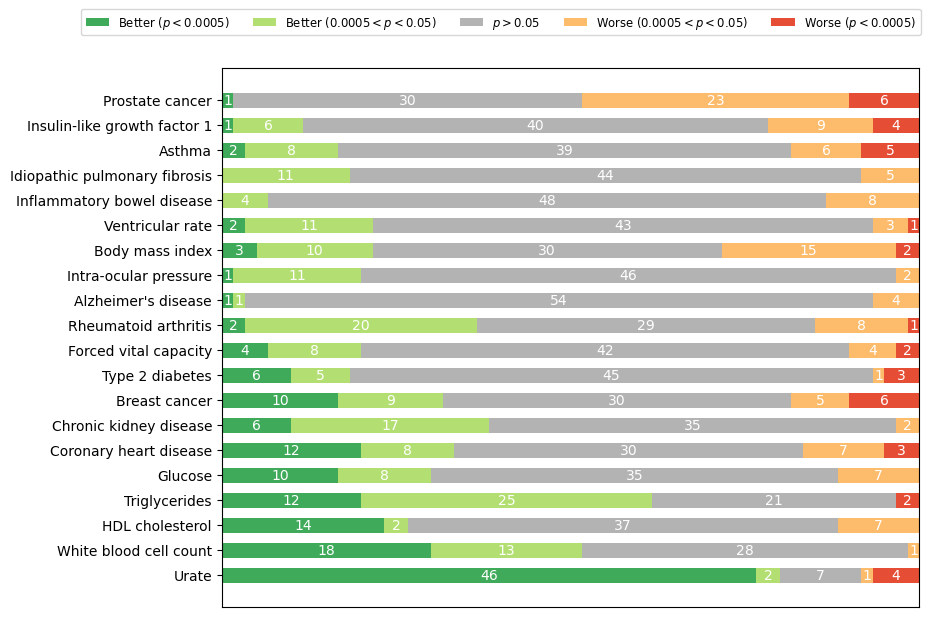

In [51]:
def plot_traits(df, topk):
    results_trait = {
        format_field_name(trait): group['diff_quantized'].value_counts(sort=False).to_list()
        for trait, group in df[df['model_id_2'].isin(model_names.keys())].groupby('ukb_field_id')
    }
    results_trait = sorted(results_trait.items(), key=lambda k: k[1][0] - k[1][-1])
    results_trait = {k: v for k, v in results_trait}

    df_results = pd.DataFrame([(k, *(np.array(v) / sum(v)).round(2)) for k, v in results_trait.items()])
    df_results['net'] = df_results[1] - df_results[5]
    display(df_results.sort_values('net'))
    
    barplot(
        results_trait, 
        CATEGORIES,
        figsize=(9, 7),
        bar_height=.6,
        legend_offset=-.21,
    )
    plt.savefig(f'pgs_results_trait_topk{topk}.png', dpi=300, bbox_inches = "tight")
    plt.show()
    
    
for topk in topks:
    df = dfs_topk[topk]
    plot_traits(df, topk)

# $R^2$ table

Model
MIFM               0.042
DeepSEA-SEI        0.040
CADD               0.040
Enformer           0.039
Basenji2           0.039
p-value            0.037
FINEMAP            0.035
PAINTOR            0.034
CAVIARBF           0.034
SuSiE              0.034
PolyFun FINEMAP    0.034
ABF                0.033
PolyFun SuSiE      0.033
Name: r2_model_2, dtype: float64

Model
PAINTOR_top5            0.043
PolyFun FINEMAP_top5    0.043
MIFM_top5               0.042
FINEMAP_top5            0.042
CAVIARBF_top5           0.042
SuSiE_top5              0.041
DeepSEA-SEI_top5        0.041
CADD_top5               0.041
ABF_top5                0.041
p-value_top5            0.040
PolyFun SuSiE_top5      0.040
Basenji2_top5           0.038
Enformer_top5           0.036
Name: r2_model_2, dtype: float64

Model
CADD_top10               0.043
MIFM_top10               0.043
PolyFun SuSiE_top10      0.042
DeepSEA-SEI_top10        0.041
PAINTOR_top10            0.041
SuSiE_top10              0.041
PolyFun FINEMAP_top10    0.041
p-value_top10            0.041
FINEMAP_top10            0.041
ABF_top10                0.039
CAVIARBF_top10           0.039
Basenji2_top10           0.038
Enformer_top10           0.038
Name: r2_model_2, dtype: float64

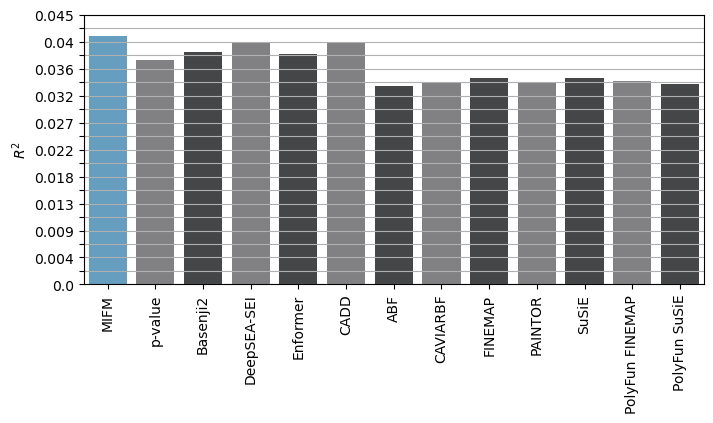

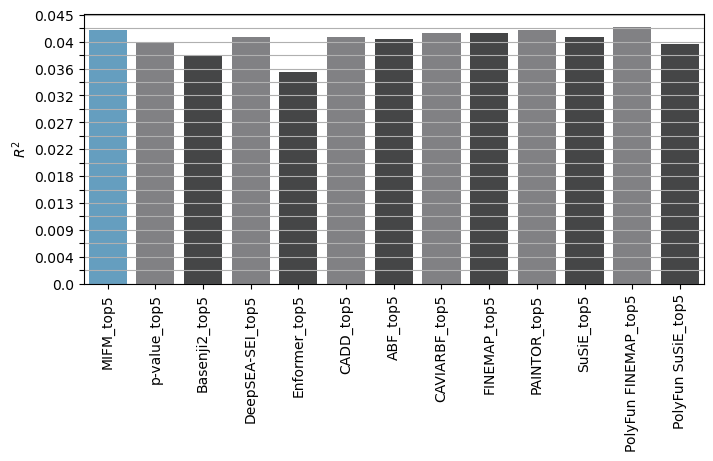

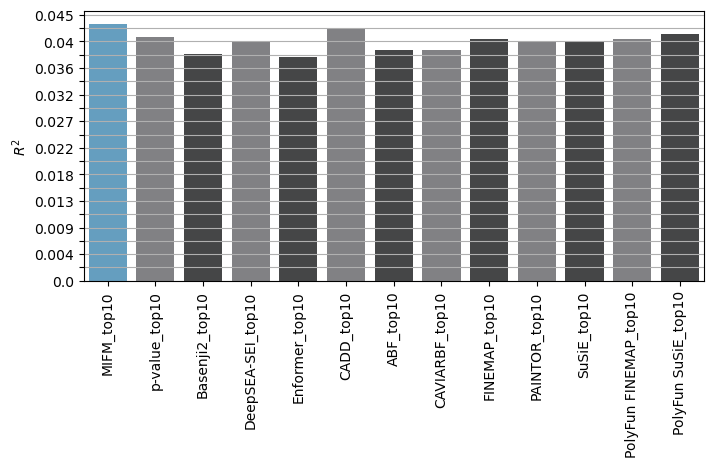

In [28]:
from matplotlib.ticker import AutoMinorLocator
pd.options.mode.chained_assignment = None

def plot_barplot(df, model_order, topk):
    mifm_name = f'MIFM_top{topk}' if topk > 1 else 'MIFM'
    
    model_order = model_order.copy()
    model_order.insert(0, mifm_name)    
    
    df = df.copy()
    
    df = df[df['model_id_2'].isin(model_names.keys())]
    
    df_mifm = df.drop_duplicates(['ukb_field_id', 'pop'])
    df_mifm['Model'] = mifm_name
    df_mifm['r2_model_2'] = df_mifm['r2_model_1']

    df['Model'] = df['model_id_2'].map(model_names)
    df = pd.concat([
        df,
        df_mifm
    ])#.dropna(subset='Model')
    df.sort_values('Model', key=lambda x: x.apply(lambda y: model_order.index(y)), inplace=True)
    display(df.groupby('Model')['r2_model_2'].mean().round(3).sort_values(ascending=False))
    
    # Get unique models
    unique_models = df['Model'].unique()

    # Create palette with gray for baseline and alternating colors for others
    palette = {}
    colors = [
        '#818084',
        '#454647',
    ]
    color_idx = 0

    for model in unique_models:
        if model == mifm_name:
            palette[model] = '#56a2ce'
        else:
            palette[model] = colors[color_idx % 2]
            color_idx += 1
            
    plt.figure(figsize=(8, 3.5))
    ax = sns.barplot(
        data=df,
        hue='Model',
        x='Model',
        y='r2_model_2',
        errorbar=None,
        palette=palette,
    )
    plt.ylabel('$R^2$')
    plt.xticks(rotation=90)
    
    all_ticks = np.linspace(0, .045, 21)
    ax.set_yticks(all_ticks)
    ax.set_yticklabels([str(round(t, 3)) if round(t, 3) in np.linspace(0, .045, 11).round(3) else '' for t in all_ticks])
    
    plt.grid(axis='y')
    plt.xlabel('')
    
    
for topk in topks:
    df = dfs_topk[topk]    
    plot_barplot(df, model_order, topk)

### All $R^2$ results table

In [31]:
def get_csv(df, topk, model_order):
    df = df.copy()
    mifm_name = f'MIFM_top{topk}' if topk > 1 else 'MIFM'
    
    model_order = model_order.copy()
    model_order.insert(0, mifm_name)   
    
    df = df[df['model_id_2'].isin(model_names.keys())]
    
    df_mifm = df.drop_duplicates(['ukb_field_id', 'pop'])
    df_mifm['model_id_2'] = mifm_name
    df_mifm['r2_model_2'] = df_mifm['r2_model_1']
    df['Model'] = df['model_id_2'].map(model_names)
    df_mifm['Model'] = mifm_name
    df = pd.concat([
        df,
        df_mifm
    ])
    
    df.sort_values('Model', key=lambda x: x.apply(lambda y: model_order.index(y)), inplace=True)
    df['Trait'] = df['ukb_field_id'].apply(format_field_name)
    df = df.rename(columns={
        'pop': 'Ancestry',
        'r2_model_2': 'R2',
    })
    
    df = df[[
        'Model',
        'Trait',
        'Ancestry',
        'R2',
    ]].sort_values(['Model', 'Trait', 'Ancestry'])
    
    return df
    
for topk in topks:
    df = dfs_topk[topk]    
    get_csv(df, topk, model_order).to_csv(
        f'pgs_results_R2_top{topk}.tsv',
        sep='\t',
        index=False,
    )